In [1]:
# importing packages
import numpy as np
from matplotlib import pyplot as plt
import math
from scipy.optimize import bisect
import pandas as pd
import conductivity as cd
from matplotlib.gridspec import GridSpec

# Data for pH effects on conductivity

In [2]:
# load LiCl simulated data
data = pd.read_csv("./Data/LiCL_pH.csv")
LiCl_conc = data["LiCl_conc"]
HCl_conc_ph2 = data["HCl_conc_ph2"]
HCl_conc_ph3 = data["HCl_conc_ph3"]
HCl_conc_ph4 = data["HCl_conc_ph4"]

# number of data points
ndata = len(LiCl_conc)

# Mean spherical approximation (MSA) model predictions

## Constants

In [3]:
# temperature in K
T = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Cl = 2.032 * 10**(-9)
Diff_Li = 1.029 * 10**(-9)
Diff_H = 9.311 * 10**(-9)
Diff_Co = 0.732 * 10**(-9)

# valencies
z_Cl = -1
z_Li = 1
z_H = 1
z_Co = 2

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Li = 2 * 74 * 10**(-12)
sigma_H = 2 * 37 * 10**(-12)
sigma_Co = 2 * 75 * 10**(-12)

# solvent viscosity in Pa.s
eta_msa = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Li_mol = 38.66 * 10**(-4)
lambda_0_H_mol = 349.65 * 10**(-4)
lambda_0_Co_mol = 55 * 10**(-4)

In [4]:
# LiCl constants
diffusion_coeff_LiCl = [Diff_Li, Diff_Cl] # diffusion coefficients of Li and Cl, respectively
valency_LiCl = [z_Li, z_Cl] # valencies of Li and Cl, respectively
diameter_LiCl = [sigma_Li, sigma_Cl] # hard sphere diameters of Li and Cl, respectively
lambda_0_Li_Cl = [lambda_0_Li_mol, lambda_0_Cl_mol] # limiting molar conductivity of Li and Cl, respectively

# LiCl and HCl constants
diffusion_coeff = [Diff_Li, Diff_Cl, Diff_H]
valency = [z_Li, z_Cl, z_H]
diameter = [sigma_Li, sigma_Cl, sigma_H]
lambda_0_Li_H_Cl = [lambda_0_Li_mol, lambda_0_Cl_mol, lambda_0_H_mol]

# calculated conductivity in milli.S/cm
all_cond_calc_con_LiCl = cd.msa(valency_LiCl, diameter_LiCl, diffusion_coeff_LiCl, T, 
                                eta_msa, epsilon, lambda_0_Li_Cl, LiCl_conc,)
all_cond_calc_con_ph2 = cd.msa(valency, diameter, diffusion_coeff, T, eta_msa, epsilon, 
                               lambda_0_Li_H_Cl, LiCl_conc, HCl_conc_ph2, acidic=True,)
all_cond_calc_con_ph3 = cd.msa(valency, diameter, diffusion_coeff, T, eta_msa, epsilon, 
                               lambda_0_Li_H_Cl, LiCl_conc, HCl_conc_ph3, acidic=True,)
all_cond_calc_con_ph4 = cd.msa(valency, diameter, diffusion_coeff, T, eta_msa, epsilon, 
                               lambda_0_Li_H_Cl, LiCl_conc, HCl_conc_ph4, acidic=True,)

# percent increase in conductivity compared to pH 7
cond_ph2_percent = [100 * (all_cond_calc_con_ph2[i] - all_cond_calc_con_LiCl[i]) / 
                    all_cond_calc_con_LiCl[i] for i in range(ndata)]
cond_ph3_percent = [100 * (all_cond_calc_con_ph3[i] - all_cond_calc_con_LiCl[i]) / 
                    all_cond_calc_con_LiCl[i] for i in range(ndata)]
print("The mean percent increase in the conductivity at pH 2 is:", 
      np.mean(cond_ph2_percent))
print("The mean percent increase in the conductivity at pH 3 is:", 
      np.mean(cond_ph3_percent))

Relaxation correction: [-0.03801212 -0.03801212]
Hydrodynamic correction: [-0.15302411 -0.0725485 ]
Relative ionic strength: [0.5 0.5]
Transport number: [0.33616465 0.66383535]
Ionic mobility: [2.49911869e+11 4.93509152e+11]
Average mobility: 371710510737.0421
Alpha: [np.float64(0.0), np.float64(351189115250.46063)]
zeta matrix: [[ 1.40525185 -1.        ]
 [ 0.71161622  1.        ]]
Relaxation correction: [-0.03215136 -0.04217944 -0.09231988]
Hydrodynamic correction: [-0.16605101 -0.07831106 -0.01886952]
Relative ionic strength: [0.41666667 0.5        0.08333333]
Transport number: [0.19307265 0.45752026 0.34940708]
Ionic mobility: [2.49911869e+11 4.93509152e+11 2.26135026e+12]
Average mobility: 539330376245.2738
Alpha: [np.float64(0.0), np.float64(339807238244.3439), np.float64(1842278565247.0125)]
zeta matrix: [[ 1.7826871  -1.41148728 -0.09553976]
 [ 0.90274853  1.15366208 -0.19951048]
 [ 0.19701268  0.13546393  1.67476169]]
Relaxation correction: [-0.03731844 -0.03851243 -0.09821235

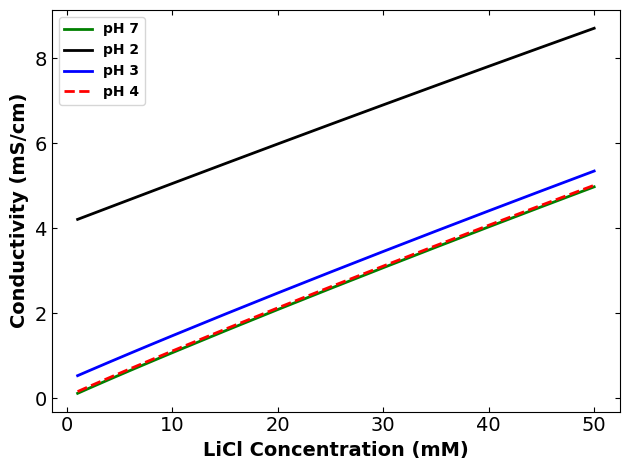

In [5]:
# plot the results
fig = plt.figure()
plt.plot(LiCl_conc, all_cond_calc_con_LiCl, "g-", linewidth=2, label="pH 7")
plt.plot(LiCl_conc, all_cond_calc_con_ph2, color="black", linestyle="-", linewidth=2, label="pH 2")
plt.plot(LiCl_conc, all_cond_calc_con_ph3, "b-", linewidth=2, label="pH 3")
plt.plot(LiCl_conc, all_cond_calc_con_ph4, color='red', linestyle='--', linewidth=2, label="pH 4")
plt.xlabel("LiCl Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(".\Li_Co\msa_licl_ph.png")
plt.show()

# Data for diafiltration experiment

In [6]:
# load the data
data = pd.read_csv('.\Data\CoCl2_pH3.csv')

# get the experiment time and measurements
experiment_time_raw = data['Time (s)']
experiment_time = [experiment_time_raw[i]/60 for i in range(len(experiment_time_raw))]
ICP_conc_raw = data['ICP-OES Concentration (mM)']
sample_pH_raw = data['Observed Sample pH']
permeate_temp = data['Permeate Temp']
permeate_conc_raw = data['Permeate Concentration (mM)']
permeate_cond_raw_micro = data['Permeate Cond @ Temp (uS/cm)']
ndata_raw = len(permeate_cond_raw_micro)

# convert the conductivity from micro.S/cm to milli.S/cm
permeate_cond_raw = [permeate_cond_raw_micro[i]/1000 for i in range(ndata_raw)]

In [7]:
# convert the conductivity at recorded temperature to 25 deg. C
temp_coeff = 0.022 # per deg. C
permeate_cond_cal = [permeate_cond_raw[i] / (1 + temp_coeff * (permeate_temp[i] - 25)) for i in range(ndata_raw)]

In [8]:
# filter out the empty measurements
ICP_conc = []
sample_pH = []
exp_time_ICP_pH = []
permeate_conc = []
permeate_cond = []
for i, t in enumerate(experiment_time):
    if not pd.isna(ICP_conc_raw[i]) and not pd.isna(sample_pH_raw[i]):
        ICP_conc.append(ICP_conc_raw[i])
        sample_pH.append(sample_pH_raw[i])
        exp_time_ICP_pH.append(t)
        permeate_conc.append(permeate_conc_raw[i])
        permeate_cond.append(permeate_cond_cal[i])

print("ICP conc. in mM:\n",ICP_conc)
print("\nPermeate cond. in micro.S/cm:\n",permeate_cond)
print("\nSample pH:\n",sample_pH)
print("\nCorresponding experiment time in min:\n",exp_time_ICP_pH)

# number of data points
ndata_pH = len(sample_pH)
print("\nThe number of data points is:",ndata_pH)

# ICP measurement error
ICP_error_percent = [0.79, 1.38, 0.35, 1.04, 1.44, 0.34, 1.13, 1.16, 0.62, 1.04]
ICP_error = [(ICP_error_percent[i] / 100) * ICP_conc[i] for i in range(ndata_pH)]

ICP conc. in mM:
 [np.float64(0.19278), np.float64(0.33504), np.float64(0.71337), np.float64(1.23054), np.float64(2.01759), np.float64(3.09497), np.float64(4.60706), np.float64(6.76483), np.float64(10.17519), np.float64(14.72702)]

Permeate cond. in micro.S/cm:
 [np.float64(0.6479544371582219), np.float64(1.3274086227326587), np.float64(1.2525407893537506), np.float64(1.0766445795477833), np.float64(0.9916530760170337), np.float64(1.1306416254209326), np.float64(1.3403226535315649), np.float64(1.8868769120028794), np.float64(2.5170197011174436), np.float64(3.2491906110886277)]

Sample pH:
 [np.float64(2.94), np.float64(2.66), np.float64(2.62), np.float64(2.71), np.float64(2.91), np.float64(3.07), np.float64(3.19), np.float64(3.26), np.float64(3.29), np.float64(3.27)]

Corresponding experiment time in min:
 [np.float64(22.009966666666667), np.float64(56.12286666666667), np.float64(80.79703333333333), np.float64(110.4561), np.float64(147.80225000000002), np.float64(196.21836666666667), n

In [9]:
# calculate the H+ concentration from the pH
H_conc = np.zeros(ndata_pH)
for i in range(ndata_pH):
    H_conc[i] = 1000 * (10 ** (-sample_pH[i]))

print("H+ conc. in mM:\n",H_conc)

H+ conc. in mM:
 [1.14815362 2.18776162 2.39883292 1.9498446  1.23026877 0.85113804
 0.64565423 0.54954087 0.51286138 0.5370318 ]


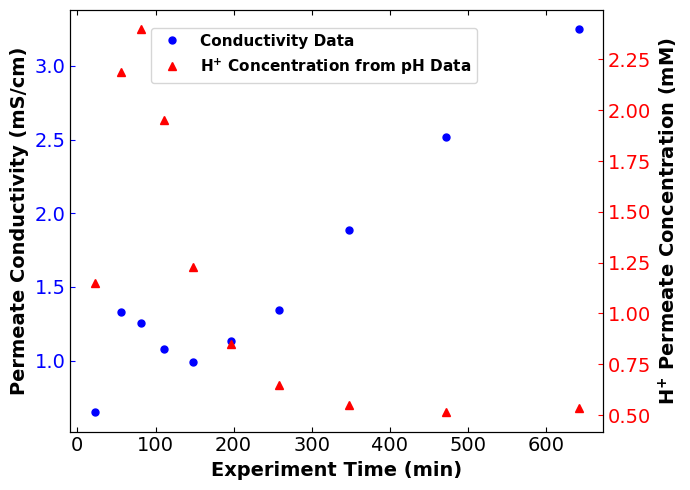

In [10]:
# plot the ICP Co2+ concentration and H+ sample concentration
fig, ax1 = plt.subplots(figsize=(7, 5))

ax1.plot(exp_time_ICP_pH, permeate_cond, "b.", markersize=10, label="Conductivity Data")
ax1.set_xlabel("Experiment Time (min)", fontsize=14,fontweight='bold')
ax1.set_ylabel("Permeate Conductivity (mS/cm)", fontsize=14,fontweight='bold')
ax1.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
ax1.tick_params(axis='y', colors="blue", labelsize=14, direction="in",top=True, right=True)

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(exp_time_ICP_pH, H_conc, "r^", label="H$^\mathbf{+}$ Concentration from pH Data")
ax2.tick_params(axis='y', colors="red", labelsize=14, direction="in",top=True, right=True)
ax2.set_ylabel("H$^\mathbf{+}$ Permeate Concentration (mM)", fontsize=14,fontweight='bold')

fig.legend(prop={"weight":"bold", "size": 11}, bbox_to_anchor=(0.7, 0.95), frameon=True)
plt.tight_layout()
plt.savefig(".\Li_Co\cocl2_data_paper.png")
plt.show()

## HCl conductivity contribution

In [11]:
# valencies
valency_H_Cl = [z_Cl, z_H]

# diffusion coefficients at infinite dilution in m^2/s
diff_coeff_H_Cl = [Diff_Cl, Diff_H]

# hard sphere diameters in m
diameter_H_Cl = [sigma_Cl, sigma_H]

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_H_Cl = [lambda_0_Cl_mol, lambda_0_H_mol]

# HCl concentration in mM
HCl_conc = H_conc

# calculate the bulk conductivity using the MSA model
HCl_cond = cd.msa(valency_H_Cl, diameter_H_Cl, diff_coeff_H_Cl, T, eta_msa, 
                  epsilon, lambda_0_H_Cl, HCl_conc, acidic=True,)

Relaxation correction: [-0.00516601 -0.00516601]
Hydrodynamic correction: [-0.00900528 -0.0019867 ]
Relative ionic strength: [0.5 0.5]
Transport number: [0.17914132 0.82085868]
Ionic mobility: [4.93509152e+11 2.26135026e+12]
Average mobility: 1377429703786.4321
Alpha: [np.float64(0.0), np.float64(1056407614413.83)]
zeta matrix: [[ 2.1406039  -1.        ]
 [ 0.46715789  1.        ]]


### H+

In [12]:
# valencies
valency_H = [z_H]

# diffusion coefficients at infinite dilution in m^2/s
diff_coeff_H = [Diff_H]

# hard sphere diameters in m
diameter_H = [sigma_H]

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_H = [lambda_0_H_mol]

# calculate the bulk conductivity using the MSA model
H_cond = cd.msa(valency_H, diameter_H, diff_coeff_H, T, eta_msa, epsilon, lambda_0_H, H_conc)

Relaxation correction: [-0.]
Hydrodynamic correction: [-0.00141471]
Relative ionic strength: [1.]
Transport number: [1.]
Ionic mobility: [2.26135026e+12]
Average mobility: 2261350255127.474
Alpha: [np.float64(0.0)]
zeta matrix: [[1.]]


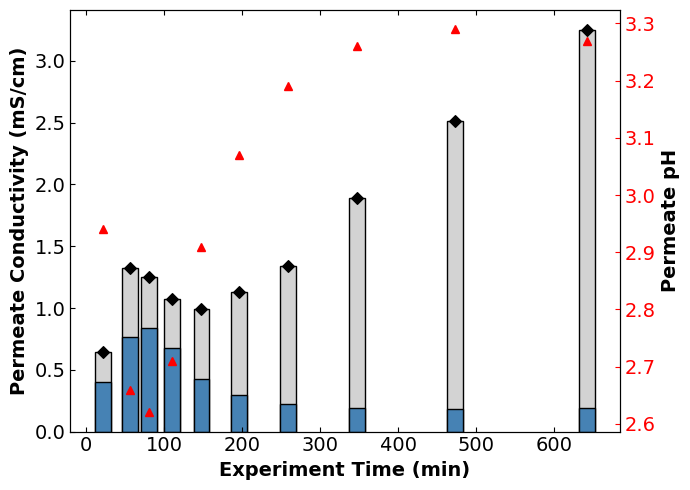

In [13]:
# plot showing the bulk permeate measurements, H+ conductivity, and true CoCl2 conductivity
fig, ax1 = plt.subplots(figsize=(7, 5))

ax1.bar(exp_time_ICP_pH, permeate_cond, color='lightgray', edgecolor='black', 
        width=20, label='MSA CoCl$_\mathbf{2}$ Conductivity')
ax1.bar(exp_time_ICP_pH, H_cond, color='steelblue', edgecolor='black', width=20, 
        label='MSA H$^\mathbf{+}$ Conductivity')
plt.scatter(exp_time_ICP_pH, permeate_cond, marker='D', s=35, color='black', 
            zorder=10, label="Conductivity Data")
ax1.set_xlabel("Experiment Time (min)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Permeate Conductivity (mS/cm)", fontsize=14,fontweight='bold')
ax1.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
ax1.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(exp_time_ICP_pH, sample_pH, "r^", label="pH Data")
ax2.tick_params(axis='y', colors='red', labelsize=14, direction="in",top=True, 
                right=True)
ax2.set_ylabel("Permeate pH", fontsize=14, fontweight='bold')

# fig.legend(prop={"weight":"bold"}, bbox_to_anchor=(0.6, 0.9))
plt.tight_layout()
plt.savefig(".\Li_Co\h_co_cl_conductivity_paper.png")
plt.show()

## MSA model Co$^{2+}$ conductivity and concentration

In [14]:
# CoCl2 and HCl constants
diff_coeff_Co_Cl_H = [Diff_Co, Diff_Cl, Diff_H]
valency_Co_Cl_H = [z_Co, z_Cl, z_H]
diameter_Co_Cl_H = [sigma_Co, sigma_Cl, sigma_H]
lambda_0_Co_Cl_H = [lambda_0_Co_mol, lambda_0_Cl_mol, lambda_0_H_mol]

In [15]:
# MSA model for a single datapoint of acidic solutions
def msa_acidic_single(valency, diameters, diff_coeff, temp, eta, epsilon, lambda_0, 
                      cat_1_conc, an_conc, H_conc):
    """Calculates the conductivity of acidic single salt solutions

    Argument:
        valency: list, valency of ions in decreasing order with hydrogen ion as the last entry
        diameters: list, corresponding hard sphere diameter of the ions in m
        diff_coeff: list, corresponding diffusion coefficient of the ions at infinite dilution in m^2/s
        temp: int or float, temperature in K
        eta: int or float, viscosity in Pa.s
        epsilon: int or float, relative permittivity
        lambda_0: list, corresponding limiting molar conductivity of the ions in S.m^2/mol
        cat_1_conc = int or float, concentration of cation 1 in mM
        an_conc = int or float, concentration of the common anion in mM
        H_conc = int or float, concentration of hydrogen ions in mM

    Returns:
        cond_calc_con: conductivity of the acidic salt solution in milli.S/cm"""

    # constants
    Avogadros_num = 6.022 * 10 ** 23  # Avogadro's constant
    k_B = 1.381 * 10 ** (-23)  # Boltzmann constant in J/K
    charge = 1.602 * 10 ** (-19)  # elementary charge in C
    epsilon_0 = 8.854 * 10 ** (-12)  # permittivity of free space in F/m
    Faraday = 96500  # Faraday's constant in C/mol

    # number of ionic species
    n_species = len(valency)

    # charge of ionic species
    ion_charge = [valency[i] * charge for i in range(len(valency))]

    # valency of cations
    valency_cation_1 = valency[0]
    valency_H = valency[2]

    # evaluating the number density of individual ionic species
    n_cat_1 = cat_1_conc * Avogadros_num
    n_H = H_conc * Avogadros_num
    n_an = an_conc * Avogadros_num

    # calculate the bulk conductivity of the salt solution
    all_cond_calc = 0
    
    # list of the number density of ionic species
    number_density = [n_cat_1, n_an, n_H]

    # alculate the ionic mobility (omega) and relative ionic strength (mew) of all species
    omega = np.zeros(n_species)
    mew = np.zeros(n_species)
    for a in range(n_species):
        omega[a] = diff_coeff[a] / (k_B * temp)
        mew[a] = number_density[a] * ion_charge[a] ** 2 / sum(
            number_density[j] * ion_charge[j] ** 2 for j in range(n_species))

    # calculate the Debye length
    kappa = math.sqrt(
        sum(number_density[l] * ion_charge[l] ** 2 / (epsilon * epsilon_0 * k_B * temp) for l in range(n_species)))

    # calculate the average mobility of all species
    omega_bar = sum(mew[j] * omega[j] for j in range(n_species))

    # calculate the transport number of all species
    transport_num = np.zeros(n_species)
    for j in range(n_species):
        transport_num[j] = mew[j] * omega[j] / omega_bar
    # print("The transport number is:",transport_num)

    # calculate the value of alpha from the equation containing alpha
    alpha_scaled = np.zeros(n_species)
    def func_alpha(alpha_scaled):
        """
        Evaluates residuals of the equation containing alpha

        Arguments:
            alpha_scaled = alpha/omega_bar

        Returns:
            residual of the equation containing alpha
        """
        return ((alpha_scaled) * sum(
            transport_num[k] / ((omega[k] / omega_bar) ** 2 - (alpha_scaled) ** 2) for k in range(n_species)))

    # since alpha is scaled by omega_bar, omega need to be scaled by same factor
    omega_scaled = np.zeros(n_species)
    for k in range(n_species):
        omega_scaled[k] = omega[k] / omega_bar
        
    # updating the values of alpha_scaled
    for p in range(n_species):
        if p == 0:
            alpha_scaled[p] = bisect(func_alpha, 0, 0.991 * omega_scaled[p])
        else:
            alpha_scaled[p] = bisect(func_alpha, 1.0001 * omega_scaled[p - 1], 0.9991 * omega_scaled[p])

    # re-scaling alpha_scaled back to alpha
    alphas = [alpha_scaled[p] * omega_bar for p in range(n_species)]

    # calculate the q and N values of all species
    q = np.zeros(n_species)
    N = np.zeros(n_species)
    for p in range(n_species):
        q[p] = sum(omega_bar * transport_num[r] / (omega[r] + alphas[p]) for r in range(n_species))
        N[p] = math.sqrt(1 / sum(
            transport_num[r] * omega[r] ** 2 / (omega[r] ** 2 - alphas[p] ** 2) ** 2 for r in range(n_species)))

    # compute the zeta matrix
    zeta = np.zeros((n_species, n_species))

    # calculate the electrophoretic correction
    delta_vel_divide_vel = np.zeros(n_species)
    for i in range(n_species):
        # update the electrophoretic correction
        prefactor = -(Faraday ** 2) * np.abs(valency[i]) / (
                    12 * math.pi * epsilon_0 * epsilon * eta * k_B * temp * Avogadros_num * lambda_0[i])
        delta_vel_divide_vel[i] = prefactor * sum(number_density[j] * ion_charge[j] ** 2 *
                                                  ((np.exp(kappa * (diameters[i] - 0.5 * (
                                                              diameters[i] + diameters[j]))) / (
                                                                kappa * (1 + kappa * diameters[i]))) +
                                                   (np.exp(kappa * (diameters[j] - 0.5 * (
                                                               diameters[i] + diameters[j]))) / (
                                                                kappa * (1 + kappa * diameters[j]))))
                                                  for j in range(n_species))

        # update the zeta matrix
        for p in range(n_species):
            zeta[i][p] = N[p] * omega[i] / (omega[i] ** 2 - alphas[p] ** 2)

    # calculate the conductivity of all ionic species
    cond_species = np.zeros(n_species)

    # calculate the relaxation correction
    delta_k_divide_k = np.zeros(n_species)
    for i in range(n_species):
        delta_k_divide_k_sum = 0.0
        for p in range(n_species):
            inner_delta_k_divide_k_sum = 0.0
            for j in range(n_species):
                for a in range(n_species):
                    # calculate the average diameter
                    sigma_aj = 0.5 * (diameters[a] + diameters[j])

                    # first fraction of summation term
                    term1 = transport_num[j] * zeta[j][p] * mew[a] * (
                            ion_charge[a] * omega[a] - ion_charge[j] * omega[j]) / (
                                    ion_charge[a] * ion_charge[j] * (omega[a] + omega[j]))

                    # second fraction of summation term
                    term2 = math.sinh(kappa * math.sqrt(q[p]) * sigma_aj) / (kappa * math.sqrt(q[p]) * sigma_aj)

                    # evaluate the integral term
                    integral_prefactor = - (charge ** 2 * valency[a] * valency[j]) / (
                                8 * math.pi * epsilon_0 * epsilon * k_B * temp)

                    integral_term1 = np.exp(kappa * diameters[j]) / (1 + kappa * diameters[j])
                    integral_term2 = np.exp(kappa * diameters[a]) / (1 + kappa * diameters[a])

                    integral_exp_term = np.exp(-kappa * (1 + np.sqrt(q[p])) * sigma_aj) / (
                                kappa * (1 + np.sqrt(q[p])))

                    integral = integral_prefactor * (integral_term1 + integral_term2) * integral_exp_term

                    inner_delta_k_divide_k_sum += term1 * term2 * integral

            delta_k_divide_k_sum += zeta[i][p] * inner_delta_k_divide_k_sum

        # update the relaxation correction
        delta_k_divide_k[i] = -(kappa ** 2) * ion_charge[i] * delta_k_divide_k_sum / 3

        # update the conductivity of all ionic species
        cond_species[i] = (charge ** 2) * number_density[i] * diff_coeff[i] * (valency[i] ** 2) * (
                1 + delta_vel_divide_vel[i]) * (1 + delta_k_divide_k[i]) / (k_B * temp)

    # calculate the bulk conductivity of the salt solution in S/m
    all_cond_calc += sum(cond_species)

    # convert the conductivity to milli.S/cm
    cond_calc_con = all_cond_calc * 10 ** 3 / 100
    
    return cond_calc_con

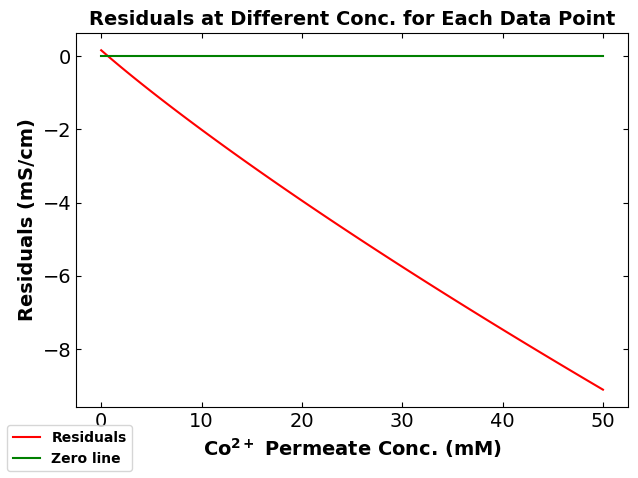

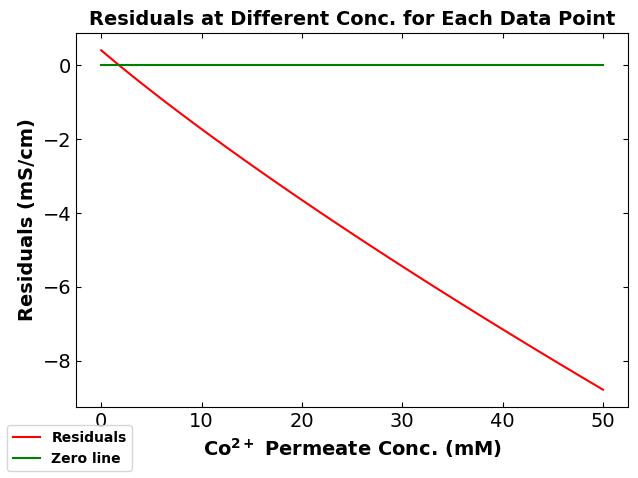

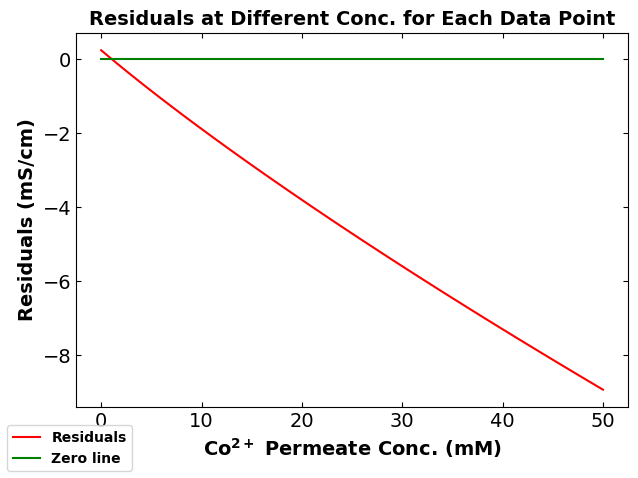

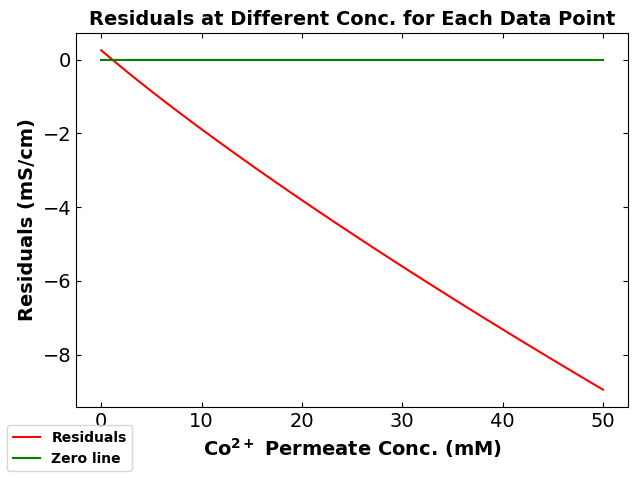

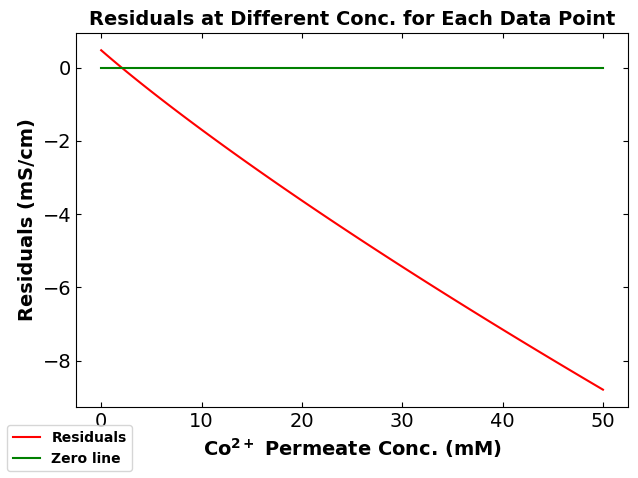

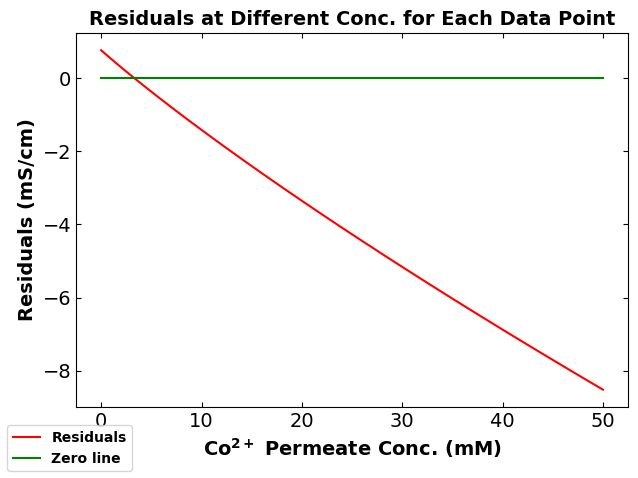

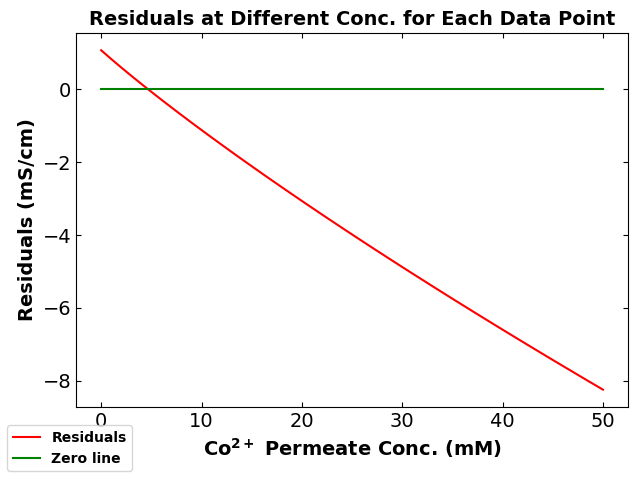

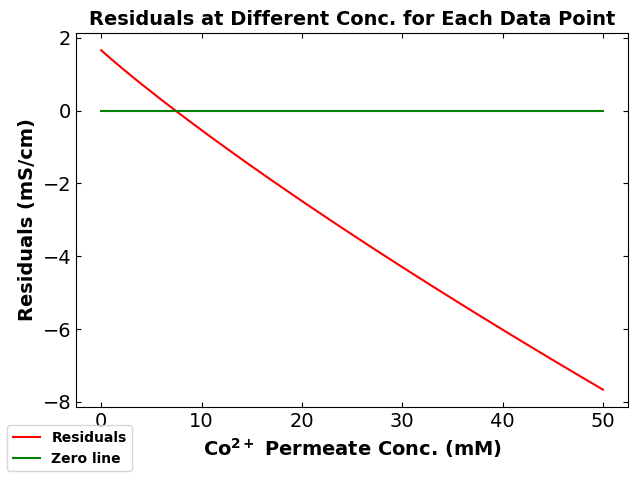

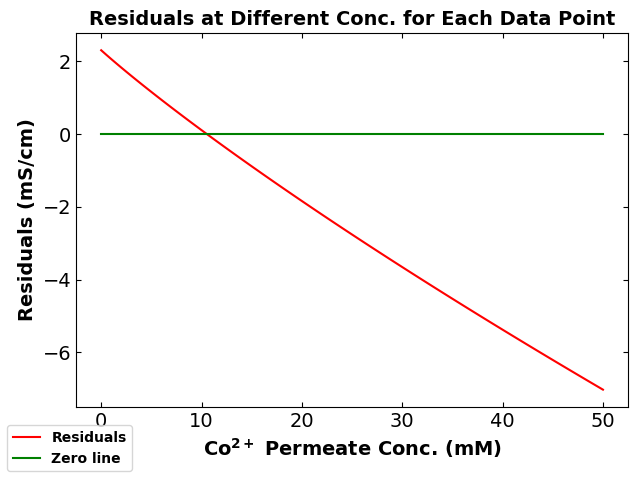

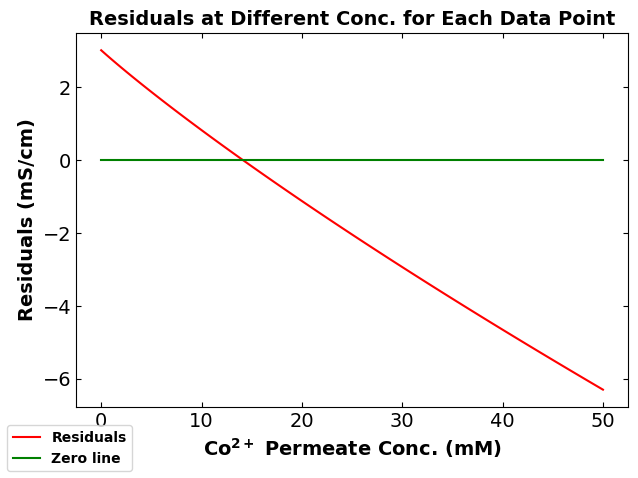

In [16]:
# soft sensor estimates of the cobalt ion concentrations
CoCl2_conc = np.zeros(ndata_pH)
for i in range(ndata_pH):
    
    # get the permeate conductivity data in milli.S/cm
    permeate_cond_single = permeate_cond[i]

    # get the hydrogen ion concentration data in mM
    H_conc_single = HCl_conc[i]

    # list of cobalt ion concentrations in mM
    Co_conc_list = np.linspace(0.001, 50, 100)

    # list of conductivity residuals
    zero_cond_residuals = np.zeros(len(Co_conc_list))
    calc_cond_residuals = []
    for j, Co_conc_single in enumerate(Co_conc_list):
        
        # calculate the chloride ion concentration
        Cl_conc_single = z_H * H_conc_single + z_Co * Co_conc_single
        
        # calculate the bulk conductivity using the MSA model
        msa_cond_single = msa_acidic_single(valency_Co_Cl_H, diameter_Co_Cl_H, diff_coeff_Co_Cl_H, 
                                            T, eta_msa, epsilon, lambda_0_Co_Cl_H, Co_conc_single, 
                                            Cl_conc_single, H_conc_single)
    
        # calculate the residuals between the measured and predicted conductivity
        calc_residuals = permeate_cond_single - msa_cond_single
            
        calc_cond_residuals.append(calc_residuals)

    # get the first negative residual and its index
    first_neg_cond = next((x for x in calc_cond_residuals if x < 0), None)
    index_first_neg = calc_cond_residuals.index(first_neg_cond)

    # get the concentration that corresponds to the first negative residual
    conc_first_neg = Co_conc_list[index_first_neg]

    # get the previous positive residual and its index
    prev_cond_value = calc_cond_residuals[index_first_neg-1]

    # get the concentration that corresponds to the previous positive residual
    prev_conc_value = Co_conc_list[index_first_neg-1]

    # calculate the concentration that produces zero residual
    CoCl2_conc[i] = prev_conc_value + (prev_cond_value / (prev_cond_value - first_neg_cond)) * (
        conc_first_neg - prev_conc_value)

    # plot the calculated conductivity residuals at various Co2+ concentration
    fig, ax1 = plt.subplots()
    
    ax1.plot(Co_conc_list, calc_cond_residuals, color="red", label="Residuals")
    ax1.plot(Co_conc_list, zero_cond_residuals, color="green", label="Zero line")
    ax1.set_xlabel("Co$^\mathbf{2+}$ Permeate Conc. (mM)", fontsize=14,fontweight='bold')
    ax1.set_ylabel("Residuals (mS/cm)", fontsize=14,fontweight='bold')
    ax1.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
    ax1.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)
    plt.title("Residuals at Different Conc. for Each Data Point", fontsize=14,fontweight='bold')
    fig.legend(prop={"weight":"bold"}, loc="lower left")
    plt.tight_layout()
    plt.show()

In [17]:
print(CoCl2_conc)

[ 0.69711234  1.81113681  1.09437709  1.12810529  2.0418641   3.34016185
  4.66318395  7.39664378 10.52315829 14.15630538]


### Plot the conductivity residuals at the estimated Co2+ concentrations

In [18]:
predicted_cond = []
for i, Co_conc in enumerate(CoCl2_conc):
    
    # get the hydrogen ion concentration data
    H_conc_single = HCl_conc[i]
        
    # calculate the chloride ion concentration
    Cl_conc_single = 1 * H_conc_single + 2 * Co_conc
    
    # calculate the bulk conductivity using the MSA model
    predicted_cond.append(msa_acidic_single(valency_Co_Cl_H, diameter_Co_Cl_H, diff_coeff_Co_Cl_H, 
                                            T, eta_msa, epsilon, lambda_0_Co_Cl_H, Co_conc, 
                                            Cl_conc_single, H_conc_single))

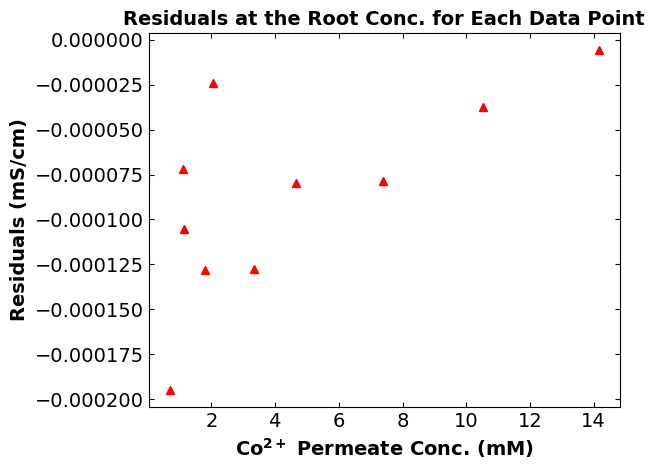

In [19]:
# calculate the residuals of the MSA conductivity predictions
cond_res = [permeate_cond[i] - predicted_cond[i] for i in range(ndata_pH)]

# plot the residuals
fig, ax1 = plt.subplots()

ax1.plot(CoCl2_conc, cond_res, "^", color="red", label="Probe-MSA")
ax1.set_xlabel("Co$^\mathbf{2+}$ Permeate Conc. (mM)", fontsize=14,fontweight='bold')
ax1.set_ylabel("Residuals (mS/cm)", fontsize=14,fontweight='bold')
ax1.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
ax1.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)
plt.title("Residuals at the Root Conc. for Each Data Point", fontsize=14,fontweight='bold')
plt.tight_layout()
# plt.savefig(".\Li_Co\msa_co_cond_resid_conc.png")
plt.show()

## Shedlovsky model Co$^{2+}$ conductivity and concentration

In [20]:
# constants
eta_shed = 8.9*10**(-3) # poise
lambda_0_HCl = 426.15 # cm^2.Siemen.equiv^(-1)
lambda_0_H = 349.8 # cm^2.Siemen.equiv^(-1)
lambda_0_Cl = 76.35 # cm^2.Siemen.equiv^(-1)
a_HCl = 4.4*10**(-8) # cm
lambda_0_CoCl2 = 131.35 # cm^2.Siemen.equiv^(-1)
lambda_0_Co = 55 # cm^2.Siemen.equiv^(-1)
a_CoCl2 = 4.5*10**(-8) # cm
a_H_Co = (a_HCl + a_CoCl2)/2

In [21]:
# Shedlovsky model for the equivalent conductivity of a single datapoint
def _equivalent_conductivity(conc, temp, epsilon, eta, lambda_0, a, z_1, z_2, 
                             lambda_0_cation, lambda_0_anion):
    """
    Calculates the equivalent conductivity of a single salt solution

    Arguments:
        conc: float or int, salt concentration in M
        temp: int or float, temperature in K
        epsilon: int or float, dielectric constant
        eta: int or float, viscosity of the salt solution in poise
        lambda_0: int or float, limiting equivalent conductivity of the salt in cm^2.S/equiv
        a: int or float, distance of closest approach of ions in cm
        z_1: int, valency of the cation
        z_2: int, valency of the anion
        lambda_0_cation: int or float, limiting equivalent conductivity of the cation in cm^2.S/equiv
        lambda_0_anion: int or float, limiting equivalent conductivity of the anion in cm^2.S/equiv

    Returns:
        equiv_cond: equivalent conductivity of the salt in cm^2.S/equiv
    """
    # calculate the B and q constants
    B = 50.29 * (10 ** 8) * (epsilon * temp) ** (-0.5)
    q = np.abs(z_1 * z_2) * (lambda_0_cation + lambda_0_anion) / ((np.abs(z_1) + np.abs(z_2)) * (
        np.abs(z_2) * lambda_0_cation + np.abs(z_1) * lambda_0_anion))

    # compute the relaxation (B1) and the electrophoretic (B2) terms
    B_1 = 2.801 * 10 ** 6 * np.abs(z_1 * z_2) * q / ((epsilon * temp) ** (3 / 2) * (1 + math.sqrt(q)))
    B_2 = 41.25 * (np.abs(z_1) + np.abs(z_2)) / (eta * (epsilon * temp) ** (1 / 2))

    # calculate the concentration of ionic species
    cation_conc = conc
    Cl_conc = np.abs(z_1) * conc

    # calculate the ionic strength
    conc_all = [cation_conc, Cl_conc]
    z = [z_1, z_2]
    I = 1 / 2 * (sum(conc_all[j] * z[j] ** 2 for j in range(len(conc_all))))

    # calculate the equivalent conductivity of the salt solution
    equiv_cond = lambda_0 - ((B_1 * lambda_0 + B_2) * math.sqrt(I) / (1 + a * B * math.sqrt(I)))

    return equiv_cond


# Shedlovsky model for the conductivity of a single datapoint
def shedlovsky(conc, temp, epsilon, eta, lambda_0, a, z_1, z_2, lambda_0_cation, lambda_0_anion):
    """
    Calculates the conductivity of single salt solutions

    Arguments:
        conc: float or int, salt concentration in M
        temp: int or float, temperature in K
        epsilon: int or float, dielectric constant
        eta: int or float, viscosity of the salt solution in poise
        lambda_0: int or float, limiting equivalent conductivity of the salt in cm^2.S/equiv
        a: int or float, distance of closest approach of ions in cm
        z_1: int, valency of the cation
        z_2: int, valency of the anion
        lambda_0_cation: int or float, limiting equivalent conductivity of the cation in cm^2.S/equiv
        lambda_0_anion: int or float, limiting equivalent conductivity of the anion in cm^2.S/equiv

    Returns:
        specific_cond_calc: conductivity of the salt solution in milli.S/cm
    """

    # calculate the equivalent conductivity of the salt solution
    equiv_cond = _equivalent_conductivity(conc, temp, epsilon, eta, lambda_0, a, 
                                          z_1, z_2, lambda_0_cation, lambda_0_anion)

    # calculate the cation concentration
    cation_conc = conc

    # convert the cation concentrations from M (mol/L) to N (equiv/L)
    equiv_conc = cation_conc * np.abs(z_1)

    # calculate the conductivity of the salt solution in S/cm
    specific_cond = (equiv_conc / 1000) * equiv_cond

    # convert the conductivity to milli.S/cm
    specific_cond_calc = specific_cond * 10 ** 3

    return specific_cond_calc

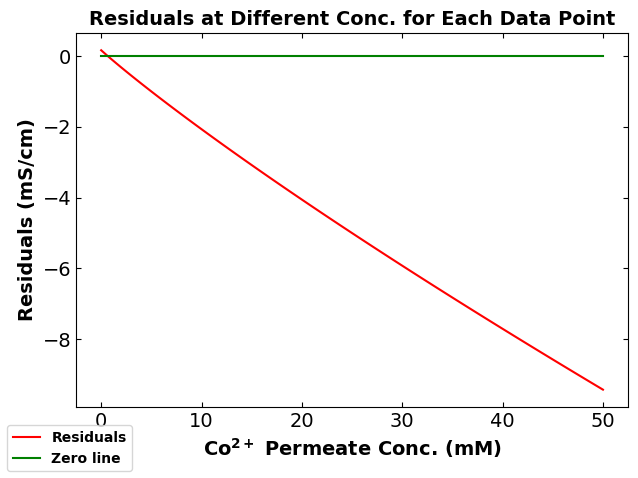

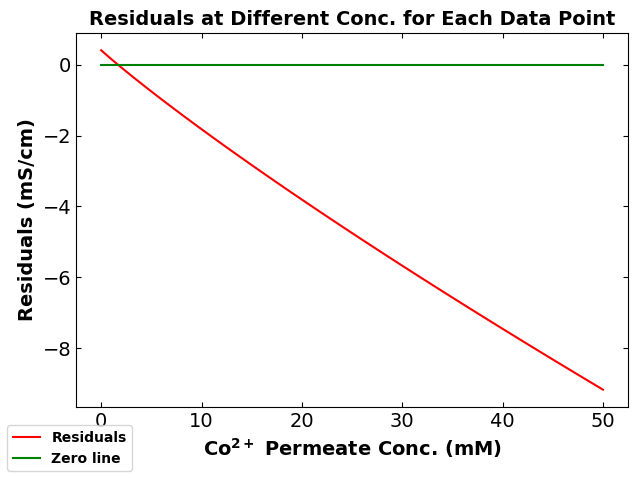

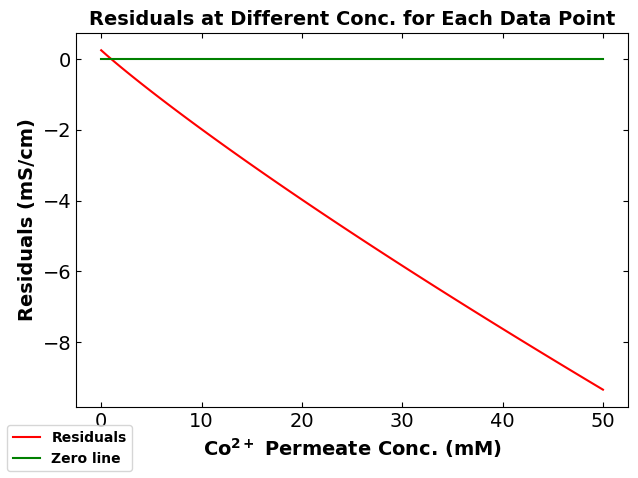

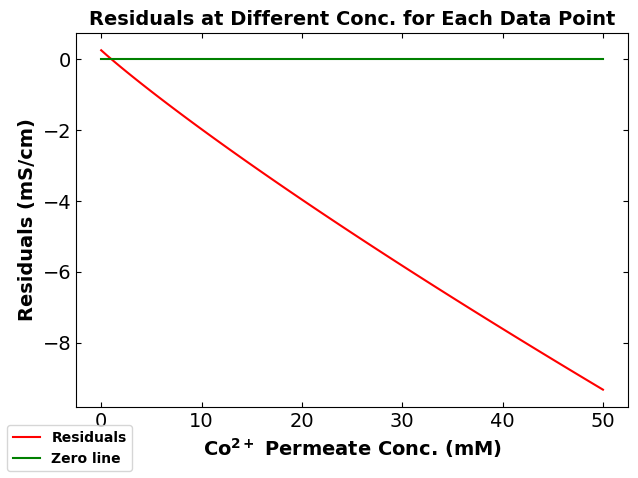

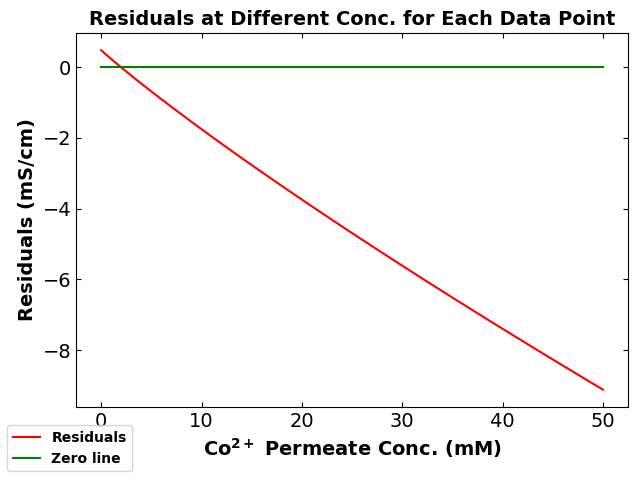

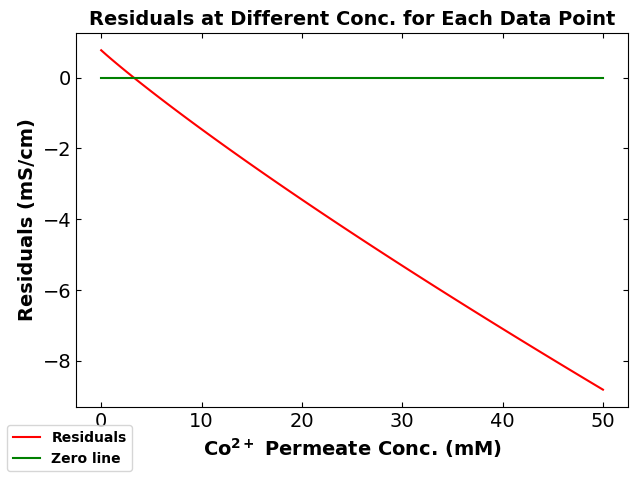

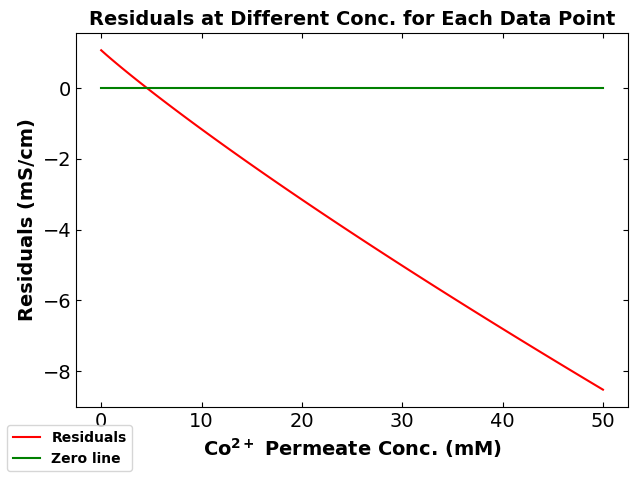

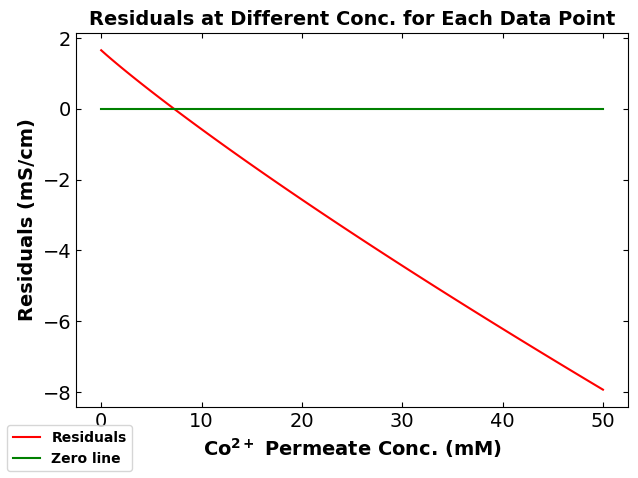

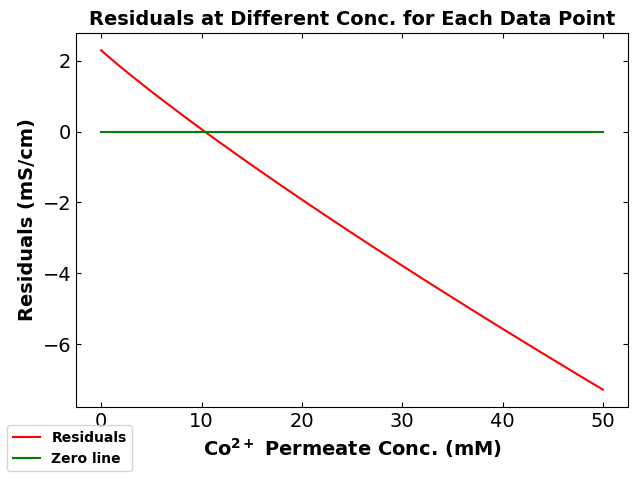

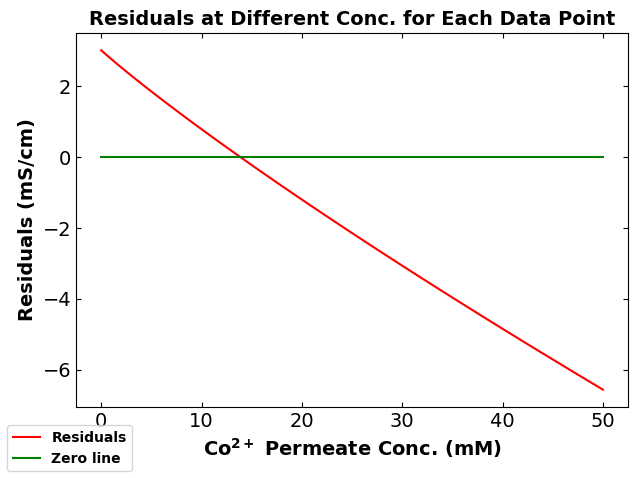

In [22]:
# soft sensor estimates of the cobalt ion concentrations
CoCl2_conc_shed = np.zeros(ndata_pH)
for i in range(ndata_pH):
    
    # get the permeate conductivity data in milli.S/cm
    permeate_cond_single = permeate_cond[i]

    # get the hydrogen ion concentration data in M
    HCl_conc_single = HCl_conc[i] * 10**(-3)

    # list of cobalt ion concentrations in mM
    Co_conc_list = np.linspace(0.001, 50, 100)

    # list of conductivity residuals
    zero_cond_residuals = np.zeros(len(Co_conc_list))
    calc_cond_residuals = []
    for j, Co_conc_single in enumerate(Co_conc_list):
        
        # HCl conductivity in milli.S/cm
        specific_cond_calc_H = shedlovsky(HCl_conc_single, T, epsilon, eta_shed, lambda_0_HCl, 
                                          a_H_Co, z_H, z_Cl, lambda_0_H, lambda_0_Cl)

        # CoCl2 conductivity in milli.S/cm
        specific_cond_calc_Co = shedlovsky(Co_conc_single * 10**(-3), T, epsilon, eta_shed, 
                                           lambda_0_CoCl2, a_H_Co, z_Co, z_Cl, lambda_0_Co, lambda_0_Cl)
        
        # calculate the bulk conductivity using the Shedlovsky model
        bulk_cond_single = specific_cond_calc_H + specific_cond_calc_Co
    
        # calculate the residuals between the measured and predicted conductivity
        calc_residuals = permeate_cond_single - bulk_cond_single
            
        calc_cond_residuals.append(calc_residuals)

    # get the first negative residual and its index
    first_neg_cond = next((x for x in calc_cond_residuals if x < 0), None)
    index_first_neg = calc_cond_residuals.index(first_neg_cond)

    # get the concentration that corresponds to the first negative residual
    conc_first_neg = Co_conc_list[index_first_neg]

    # get the previous positive residual and its index
    prev_cond_value = calc_cond_residuals[index_first_neg-1]

    # get the concentration that corresponds to the previous positive residual
    prev_conc_value = Co_conc_list[index_first_neg-1]

    # calculate the concentration that produces zero residual
    CoCl2_conc_shed[i] = prev_conc_value + (prev_cond_value / (
        prev_cond_value - first_neg_cond)) * (conc_first_neg - prev_conc_value)

    # plot the calculated conductivity residuals at various Co2+ concentration
    fig, ax1 = plt.subplots()
    
    ax1.plot(Co_conc_list, calc_cond_residuals, color="red", label="Residuals")
    ax1.plot(Co_conc_list, zero_cond_residuals, color="green", label="Zero line")
    ax1.set_xlabel("Co$^\mathbf{2+}$ Permeate Conc. (mM)", fontsize=14,fontweight='bold')
    ax1.set_ylabel("Residuals (mS/cm)", fontsize=14,fontweight='bold')
    ax1.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
    ax1.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)
    plt.title("Residuals at Different Conc. for Each Data Point", fontsize=14,fontweight='bold')
    fig.legend(prop={"weight":"bold"}, loc="lower left")
    plt.tight_layout()
    plt.show()

In [23]:
print(CoCl2_conc_shed)

[ 0.65749778  1.68056917  0.99806634  1.04332526  1.95092052  3.24364697
  4.56229633  7.26222114 10.33820445 13.89045923]


## Compare the soft sensors estimate of Co$^{2+}$ concentrations with ICP-OES data

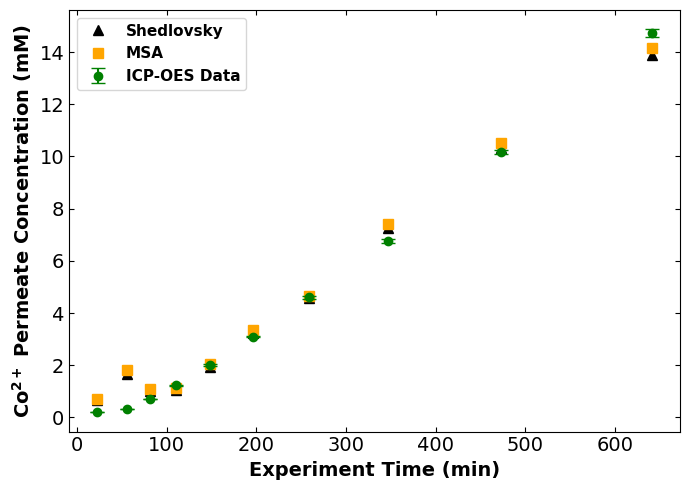

In [24]:
fig = plt.figure(figsize=(7, 5))
plt.plot(exp_time_ICP_pH, CoCl2_conc_shed, "^", color="black", markersize=7, 
         label="Shedlovsky")
plt.plot(exp_time_ICP_pH, CoCl2_conc, "s", color="orange", markersize=7, 
         label="MSA")
plt.errorbar(
    exp_time_ICP_pH, ICP_conc, yerr=ICP_error, fmt='.', ecolor='green', capsize=5, 
    markersize=12, markerfacecolor='green', markeredgecolor='green', label='ICP-OES Data')
plt.xlabel("Experiment Time (min)", fontsize=14,fontweight='bold')
plt.ylabel("Co$^\mathbf{2+}$ Permeate Concentration (mM)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight": "bold", "size": 11})
plt.tight_layout()
plt.savefig(".\Li_Co\soft_sensor_icp_co_conc_paper.png")
plt.show()

The mean absolute percent error of the MSA-based soft sensor is: 5.0432464693131465
The mean absolute percent error of the Shedlovsky-based soft sensor is: 5.56129003309369


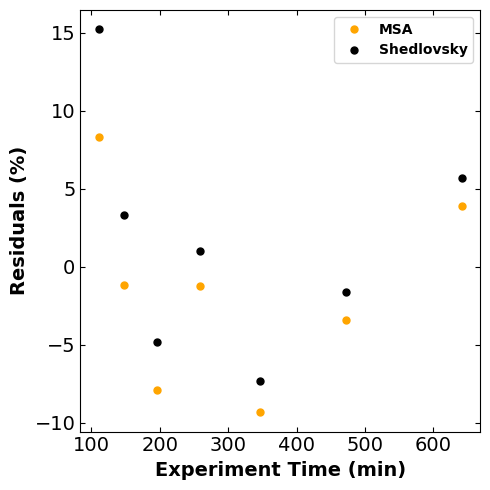

In [25]:
# prediction residuals of the soft sensors
e_msa = [ICP_conc[i] - CoCl2_conc[i] for i in range(ndata_pH)]
e_shed = [ICP_conc[i] - CoCl2_conc_shed[i] for i in range(ndata_pH)]

# percent prediction residuals
residuals_percent_msa = [100*e_msa[i]/ICP_conc[i] for i in range(ndata_pH)]
residuals_percent_shed = [100*e_shed[i]/ICP_conc[i] for i in range(ndata_pH)]

# calculate the mean absolute percent error
residuals_percent_abs_msa = [np.abs(residuals_percent_msa[i]) for i in range(ndata_pH)]
residuals_percent_abs_shed = [np.abs(residuals_percent_shed[i]) for i in range(ndata_pH)]
print("The mean absolute percent error of the MSA-based soft sensor is:", 
      np.mean(residuals_percent_abs_msa[3:]))
print("The mean absolute percent error of the Shedlovsky-based soft sensor is:", 
      np.mean(residuals_percent_abs_shed[3:]))

# plot the percent residuals of the soft sensors
fig = plt.figure(figsize=(5, 5))

plt.plot(exp_time_ICP_pH[3:], residuals_percent_msa[3:], ".", color="orange", markersize=10, 
         label="MSA")
plt.plot(exp_time_ICP_pH[3:], residuals_percent_shed[3:], ".", color="black", markersize=10, 
         label="Shedlovsky")
plt.xlabel("Experiment Time (min)", fontsize=14, fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(".\Li_Co\soft_sensor_co_conc_resid_paper.png")
plt.show()

#  Single salt conductivity predictions for paper supplementary information

## HCl

In [26]:
# loading HCl specific conductivity data
specific_data = pd.read_csv("./Data/HCl.csv")
molar_conc_specific_H = specific_data["Conc"]
specific_cond_H_raw = specific_data["Cond"]

# number of data points
ndata_H = len(specific_cond_H_raw)

# convert the conductivity from micro.S/cm to milli.S/cm
specific_cond_H = [specific_cond_H_raw[i]/1000 for i in range(ndata_H)]

# measurement error in %
sigma_cond = 0.93

# measurement error in milli.S/cm
error_H = [(sigma_cond/100) * specific_cond_H[i] for i in range(ndata_H)]

### Shedlovsky model

In [27]:
# concentration in M
conc_H = [molar_conc_specific_H[i]*10**(-3) for i in range(ndata_H)]

# HCl conductivity in milli.S/cm
specific_cond_calc_H = cd.shedlovsky(conc_H, T, epsilon, eta_shed, lambda_0_HCl, 
                                     a_HCl, z_H, z_Cl, lambda_0_H, lambda_0_Cl)

# prediction residuals
e_HCl_shed = [specific_cond_calc_H[i] - specific_cond_H[i] for i in range(ndata_H)]

# percent prediction residuals
residuals_percent_HCl_shed = [100*e_HCl_shed[i]/specific_cond_H[i] for i in range(ndata_H)]

# calculate the mean absolute percent error
residuals_percent_HCl_abs_shed = [np.abs(residuals_percent_HCl_shed[i]) for i in range(ndata_H)]
print("\nThe mean absolute percent error of HCl is:", np.mean(residuals_percent_HCl_abs_shed))

# calculate the mean absolute error
e_HCl_abs_shed = [np.abs(e_HCl_shed[i]) for i in range(ndata_H)]
print("\nThe mean absolute error of HCl is:",np.mean(e_HCl_abs_shed))

# calculate the mean squared error
sq_residuals_HCl_shed = [e_HCl_shed[i]**2 for i in range(ndata_H)]
print("\nThe mean squared error of HCl is:",np.mean(sq_residuals_HCl_shed))


The mean absolute percent error of HCl is: 4.4563500679680645

The mean absolute error of HCl is: 0.31775194131209766

The mean squared error of HCl is: 0.23686285197387616


### MSA model

In [28]:
# constants
diffusion_coeff_HCl = [Diff_Cl, Diff_H]
valency_HCl = [z_Cl, z_H]
diameter_HCl = [sigma_Cl, sigma_H]
lambda_0_H_Cl = [lambda_0_Cl_mol, lambda_0_H_mol]

# predicted conductivity in milli.S/cm
cond_HCl = cd.msa(valency_HCl, diameter_HCl, diffusion_coeff_HCl, T, 
                  eta_msa, epsilon, lambda_0_H_Cl, molar_conc_specific_H, 
                  acidic=True)

# prediction residuals
e_HCl = [cond_HCl[i] - specific_cond_H[i] for i in range(ndata_H)]

# percent prediction residuals
residuals_percent_HCl = [100*e_HCl[i]/specific_cond_H[i] for i in range(ndata_H)]

# calculate the mean absolute percent error
residuals_percent_HCl_abs = [np.abs(residuals_percent_HCl[i]) for i in range(ndata_H)]
print("\nThe mean absolute percent error of HCl is:", np.mean(residuals_percent_HCl_abs))

# calculate the mean absolute error
e_HCl_abs = [np.abs(e_HCl[i]) for i in range(ndata_H)]
print("\nThe mean absolute error of HCl is:",np.mean(e_HCl_abs))

# calculate the mean squared error
sq_residuals_HCl = [e_HCl[i]**2 for i in range(ndata_H)]
print("\nThe mean squared error of HCl is:",np.mean(sq_residuals_HCl))

Relaxation correction: [-0.05097069 -0.05097069]
Hydrodynamic correction: [-0.09722145 -0.02398691]
Relative ionic strength: [0.5 0.5]
Transport number: [0.17914132 0.82085868]
Ionic mobility: [4.93509152e+11 2.26135026e+12]
Average mobility: 1377429703786.4321
Alpha: [np.float64(0.0), np.float64(1056407614413.83)]
zeta matrix: [[ 2.1406039  -1.        ]
 [ 0.46715789  1.        ]]

The mean absolute percent error of HCl is: 4.399061721551646

The mean absolute error of HCl is: 0.34607964125341467

The mean squared error of HCl is: 0.3260983172322868


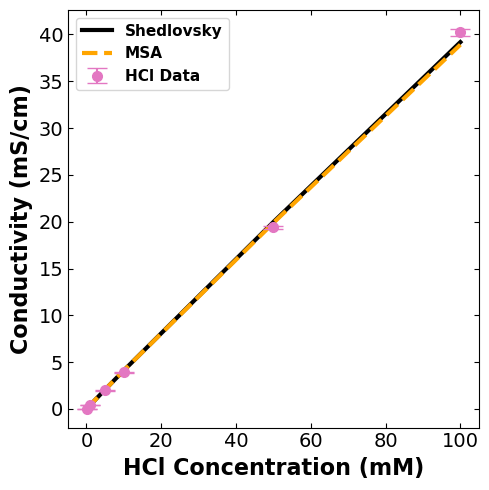

In [29]:
# plot comparing the model predictions with the data
fig = plt.figure(figsize=(5,5))
plt.plot(molar_conc_specific_H, specific_cond_calc_H, "-", color="black", 
         linewidth=3, label="Shedlovsky")
plt.plot(molar_conc_specific_H, cond_HCl, "--", color="orange", linewidth=3, 
         label="MSA")
plt.errorbar(
    molar_conc_specific_H, specific_cond_H, yerr=error_H, fmt='o', ecolor='tab:pink', 
    capsize=7, markersize=7, markerfacecolor='tab:pink', markeredgecolor='tab:pink', 
    label='HCl Data')
plt.xlabel("HCl Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold", "size": 11})
plt.tight_layout()
plt.savefig(".\Li_Co\msa_hcl_paper.png")
plt.show()

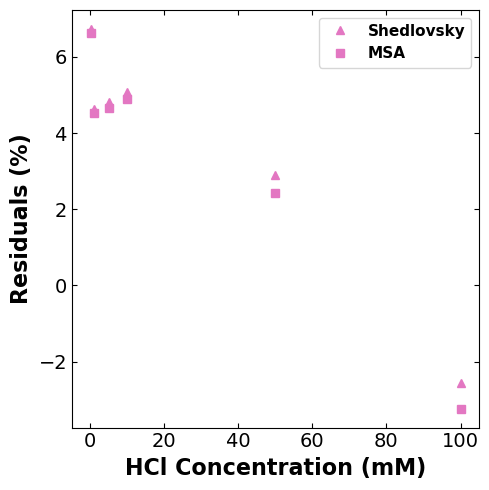

In [30]:
# visualizing the percent prediction residuals
fig = plt.figure(figsize=(5,5))
plt.plot(molar_conc_specific_H, residuals_percent_HCl_shed, "^", color="tab:pink", 
         label="Shedlovsky")
plt.plot(molar_conc_specific_H, residuals_percent_HCl, "s", color="tab:pink", 
         label="MSA")
plt.xlabel("HCl Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold", "size": 11})
plt.tight_layout()
plt.savefig(r".\Li_Co\proportion_msa_hcl_paper.png")
plt.show()

## CoCl2

In [31]:
# loading CoCl2 specific conductivity data
specific_data = pd.read_csv("./Data/CoCl2.csv")
molar_conc_specific_Co = specific_data["Conc"]
specific_cond_Co_raw = specific_data["Cond"]

# number of data points
ndata_Co = len(specific_cond_Co_raw)

# convert the conductivity from micro.S/cm to milli.S/cm
specific_cond_Co = [specific_cond_Co_raw[i]/1000 for i in range(ndata_Co)]

# measurement error in milli.S/cm
error_Co = [(sigma_cond/100) * specific_cond_Co[i] for i in range(ndata_Co)]

### Shedlovsky model

In [32]:
# concentration in M
conc_Co = [molar_conc_specific_Co[i]*10**(-3) for i in range(ndata_Co)]

# CoCl2 conductivity in milli.S/cm
specific_cond_calc_Co = cd.shedlovsky(conc_Co, T, epsilon, eta_shed, lambda_0_CoCl2, 
                                      a_CoCl2, z_Co, z_Cl, lambda_0_Co, lambda_0_Cl)

# prediction residuals
e_CoCl2_shed = [specific_cond_calc_Co[i] - specific_cond_Co[i] for i in range(ndata_Co)]

# percent prediction residuals
residuals_percent_CoCl2_shed = [100*e_CoCl2_shed[i]/specific_cond_Co[i] 
                                for i in range(ndata_Co)]

# calculate the mean absolute percent error
residuals_percent_CoCl2_abs_shed = [np.abs(residuals_percent_CoCl2_shed[i]) 
                                    for i in range(ndata_Co)]
print("\nThe mean absolute percent error of CoCl2 is:", 
      np.mean(residuals_percent_CoCl2_abs_shed))

# calculate the mean absolute error
e_CoCl2_abs_shed = [np.abs(e_CoCl2_shed[i]) for i in range(ndata_Co)]
print("\nThe mean absolute error of CoCl2 is:",np.mean(e_CoCl2_abs_shed))

# calculate the mean squared error
sq_residuals_CoCl2_shed = [e_CoCl2_shed[i]**2 for i in range(ndata_Co)]
print("\nThe mean squared error of CoCl2 is:",np.mean(sq_residuals_CoCl2_shed))


The mean absolute percent error of CoCl2 is: 4.451226326397849

The mean absolute error of CoCl2 is: 0.13238426225693406

The mean squared error of CoCl2 is: 0.02474211859122551


### MSA model

In [33]:
# diffusion coefficients at infinite dilution in m^2/s
diffusion_coeff = [Diff_Co, Diff_Cl]

# valencies
valency = [z_Co, z_Cl]

# hard sphere diameters in m
diameter = [sigma_Co, sigma_Cl]

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Co_Cl = [lambda_0_Co_mol, lambda_0_Cl_mol]

In [34]:
# predicted conductivity in milli.S/cm
cond_CoCl2 = cd.msa(valency, diameter, diffusion_coeff, T, eta_msa, epsilon, 
                    lambda_0_Co_Cl, molar_conc_specific_Co)

# prediction residuals
e_CoCl2 = [cond_CoCl2[i] - specific_cond_Co[i] for i in range(ndata_Co)]

# percent prediction residuals
residuals_percent_CoCl2 = [100*e_CoCl2[i]/specific_cond_Co[i] for i in range(ndata_Co)]

# calculate the mean absolute percent error
residuals_percent_CoCl2_abs = [np.abs(residuals_percent_CoCl2[i]) for i in range(ndata_Co)]
print("\nThe mean absolute percent error of CoCl2 is:", np.mean(residuals_percent_CoCl2_abs))

# calculate the mean absolute error
e_CoCl2_abs = [np.abs(e_CoCl2[i]) for i in range(ndata_Co)]
print("\nThe mean absolute error of CoCl2 is:",np.mean(e_CoCl2_abs))

# calculate the mean squared error
sq_residuals_CoCl2 = [e_CoCl2[i]**2 for i in range(ndata_Co)]
print("\nThe mean squared error of CoCl2 is:",np.mean(sq_residuals_CoCl2))

Relaxation correction: [-0.09585508 -0.09585508]
Hydrodynamic correction: [-0.3468368  -0.11287597]
Relative ionic strength: [0.66666667 0.33333333]
Transport number: [0.4187643 0.5812357]
Ionic mobility: [1.77779872e+11 4.93509152e+11]
Average mobility: 283022965378.78674
Alpha: [np.float64(0.0), np.float64(346930734284.36536)]
zeta matrix: [[ 1.42250053 -0.60371383]
 [ 0.51243621  1.20742767]]

The mean absolute percent error of CoCl2 is: 3.4589397186576663

The mean absolute error of CoCl2 is: 0.08071602452079955

The mean squared error of CoCl2 is: 0.009763444955041074


## LiCl

In [35]:
# loading LiCl conductivity data
specific_data = pd.read_csv("./Data/LiCl.csv")
molar_conc_specific_Li = specific_data["Conc"]
specific_cond_Li_raw = specific_data["Cond"]

# number of data points
ndata_Li = len(specific_cond_Li_raw)

# convert the conductivity from micro.S/cm to milli.S/cm
specific_cond_Li = [specific_cond_Li_raw[i]/1000 for i in range(ndata_Li)]

# measurement error in milli Siemen per cm
error_Li = [(sigma_cond/100) * specific_cond_Li[i] for i in range(ndata_Li)]

### Shedlovsky model

In [36]:
# constants
lambda_0_LiCl = 114.95 # cm^2.Siemen.equiv^(-1)
lambda_0_Li = 38.6 # cm^2.Siemen.equiv^(-1)
a_LiCl = 5.2*10**(-8) # cm

In [37]:
# concentration in M
conc_Li = [molar_conc_specific_Li[i]*10**(-3) for i in range(ndata_Li)]

# LiCl conductivity in milli.S/cm
specific_cond_calc_Li = cd.shedlovsky(conc_Li, T, epsilon, eta_shed, lambda_0_LiCl, 
                                      a_LiCl, z_Li, z_Cl, lambda_0_Li, lambda_0_Cl)

# prediction residuals
e_LiCl_shed = [specific_cond_calc_Li[i] - specific_cond_Li[i] for i in range(ndata_Li)]

# percent prediction residuals
residuals_percent_LiCl_shed = [100*e_LiCl_shed[i]/specific_cond_Li[i] for i in range(ndata_Li)]

# calculate the mean absolute percent error
residuals_percent_LiCl_abs_shed = [np.abs(residuals_percent_LiCl_shed[i]) 
                                   for i in range(ndata_Li)]
print("\nThe mean absolute percent error of LiCl is:", np.mean(residuals_percent_LiCl_abs_shed))

# calculate the mean absolute error
e_LiCl_abs_shed = [np.abs(e_LiCl_shed[i]) for i in range(ndata_Li)]
print("\nThe mean absolute error of LiCl is:",np.mean(e_LiCl_abs_shed))

# calculate the mean squared error
sq_residuals_LiCl_shed = [e_LiCl_shed[i]**2 for i in range(ndata_Li)]
print("\nThe mean squared error of LiCl is:",np.mean(sq_residuals_LiCl_shed))


The mean absolute percent error of LiCl is: 5.943980404204133

The mean absolute error of LiCl is: 0.10409395844152496

The mean squared error of LiCl is: 0.0170478184768217


### MSA model

In [38]:
# predicted conductivity in milli.S/cm
cond_LiCl = cd.msa(valency_LiCl, diameter_LiCl, diffusion_coeff_LiCl, T, 
                   eta_msa, epsilon, lambda_0_Li_Cl, molar_conc_specific_Li)

# prediction residuals
e_LiCl = [cond_LiCl[i] - specific_cond_Li[i] for i in range(ndata_Li)]

# percent prediction residuals
residuals_percent_LiCl = [100*e_LiCl[i]/specific_cond_Li[i] for i in range(ndata_Li)]

# calculate the mean absolute percent error
residuals_percent_LiCl_abs = [np.abs(residuals_percent_LiCl[i]) for i in range(ndata_Li)]
print("\nThe mean absolute percent error of LiCl is:", np.mean(residuals_percent_LiCl_abs))

# calculate the mean absolute error
e_LiCl_abs = [np.abs(e_LiCl[i]) for i in range(ndata_Li)]
print("\nThe mean absolute error of LiCl is:",np.mean(e_LiCl_abs))

# calculate the mean squared error
sq_residuals_LiCl = [e_LiCl[i]**2 for i in range(ndata_Li)]
print("\nThe mean squared error of LiCl is:",np.mean(sq_residuals_LiCl))

Relaxation correction: [-0.03801212 -0.03801212]
Hydrodynamic correction: [-0.15302411 -0.0725485 ]
Relative ionic strength: [0.5 0.5]
Transport number: [0.33616465 0.66383535]
Ionic mobility: [2.49911869e+11 4.93509152e+11]
Average mobility: 371710510737.0421
Alpha: [np.float64(0.0), np.float64(351189115250.46063)]
zeta matrix: [[ 1.40525185 -1.        ]
 [ 0.71161622  1.        ]]

The mean absolute percent error of LiCl is: 5.286366737282732

The mean absolute error of LiCl is: 0.08391082605125814

The mean squared error of LiCl is: 0.01029696245243853


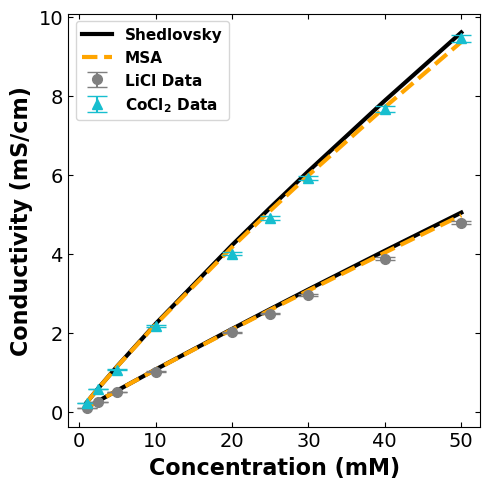

In [39]:
# plot comparing the model predictions with the data
fig = plt.figure(figsize=(5,5))
plt.plot(molar_conc_specific_Li, specific_cond_calc_Li, "-", color="black", 
         linewidth=3, label="Shedlovsky")
plt.plot(molar_conc_specific_Co, specific_cond_calc_Co, "-", color="black", 
         linewidth=3)
plt.plot(molar_conc_specific_Li, cond_LiCl, "--", color="orange", linewidth=3, 
         label="MSA")
plt.plot(molar_conc_specific_Co, cond_CoCl2, "--", color="orange", linewidth=3)
plt.errorbar(
    molar_conc_specific_Li, specific_cond_Li, yerr=error_Li, fmt='o', ecolor='tab:gray', 
    capsize=7, markersize=7, markerfacecolor='tab:gray', markeredgecolor='tab:gray', 
    label='LiCl Data')
plt.errorbar(
    molar_conc_specific_Co, specific_cond_Co, yerr=error_Co, fmt='^', ecolor='tab:cyan', 
    capsize=7, markersize=7, markerfacecolor='tab:cyan', markeredgecolor='tab:cyan', 
    label='CoCl$\mathbf{_2}$ Data')
plt.xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold", "size": 11})
plt.tight_layout()
plt.savefig(".\Li_Co\msa_li_co_paper.png")
plt.show()

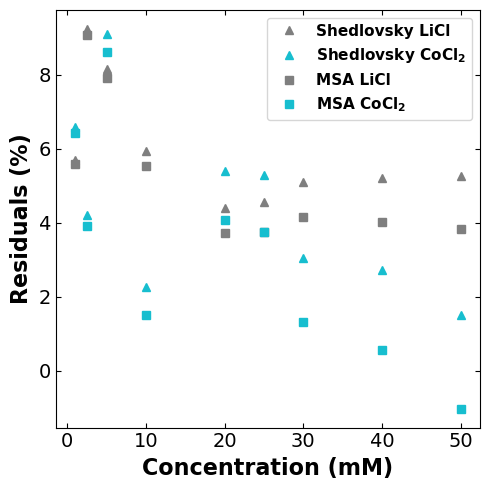

In [40]:
# visualizing the percent prediction residuals
fig = plt.figure(figsize=(5,5))
plt.plot(molar_conc_specific_Li, residuals_percent_LiCl_shed, "^", 
         color="tab:gray", label="Shedlovsky LiCl")
plt.plot(molar_conc_specific_Co, residuals_percent_CoCl2_shed, "^", 
         color="tab:cyan", label="Shedlovsky CoCl$\mathbf{_2}$")
plt.plot(molar_conc_specific_Li, residuals_percent_LiCl, "s", color="tab:gray", 
         label="MSA LiCl")
plt.plot(molar_conc_specific_Co, residuals_percent_CoCl2, "s", color="tab:cyan", 
         label="MSA CoCl$\mathbf{_2}$")
plt.xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold", "size": 11})
plt.tight_layout()
plt.savefig(r".\Li_Co\proportion_msa_li_co_paper.png")
plt.show()

# Conductivity predictions for the diafiltration CoCl$_{2}$ feed solution at pH 3

In [41]:
# loading the diafiltration CoCl2 feed conductivity data at pH 3
specific_data = pd.read_csv("./Data/CoCl2_ph3_calibration.csv")
molar_conc_specific_Co_ph3 = specific_data["Conc"]
specific_cond_Co_ph3_raw = specific_data["Cond"]

# number of data points
ndata_Co_ph3 = len(specific_cond_Co_ph3_raw)

# convert the conductivity from micro.S/cm to milli.S/cm
specific_cond_Co_ph3 = [specific_cond_Co_ph3_raw[i]/1000 
                        for i in range(ndata_Co_ph3)]

# measurement error in milli.S/cm
error_Co_ph3 = [(sigma_cond/100) * specific_cond_Co_ph3[i] 
                for i in range(ndata_Co_ph3)]

In [42]:
# calculate the H+ concentration from pH 3
H_conc_ph3_single = 1000 * (10 ** (-3))
H_conc_ph3 = [H_conc_ph3_single for i in range(ndata_Co_ph3)]

## MSA model

In [43]:
msa_cond_Co_H_ph3 = cd.msa(valency_Co_Cl_H, diameter_Co_Cl_H, diff_coeff_Co_Cl_H, T, eta_msa, 
                           epsilon, lambda_0_Co_Cl_H, molar_conc_specific_Co_ph3, H_conc_ph3, 
                           acidic=True,)

# prediction residuals
e_CoCl2_ph3_msa = [msa_cond_Co_H_ph3[i] - specific_cond_Co_ph3[i] for i in range(ndata_Co_ph3)]

# percent prediction residuals
residuals_percent_CoCl2_ph3_msa = [100*e_CoCl2_ph3_msa[i]/specific_cond_Co_ph3[i] 
                                   for i in range(ndata_Co_ph3)]

# calculate the mean absolute percent error
residuals_percent_CoCl2_ph3_abs_msa = [np.abs(residuals_percent_CoCl2_ph3_msa[i]) 
                                       for i in range(ndata_Co_ph3)]
print("\nThe mean absolute percent error of CoCl2 at pH 3 is:", 
      np.mean(residuals_percent_CoCl2_ph3_abs_msa))

# calculate the mean absolute error
e_CoCl2_ph3_abs_msa = [np.abs(e_CoCl2_ph3_msa[i]) for i in range(ndata_Co_ph3)]
print("\nThe mean absolute error of CoCl2 at pH 3 is:",np.mean(e_CoCl2_ph3_abs_msa))

# calculate the mean squared error
sq_residuals_CoCl2_ph3_msa = [e_CoCl2_ph3_msa[i]**2 for i in range(ndata_Co_ph3)]
print("\nThe mean squared error of CoCl2 at pH 3 is:",np.mean(sq_residuals_CoCl2_ph3_msa))

Relaxation correction: [-0.09525431 -0.09587202 -0.15764306]
Hydrodynamic correction: [-0.34779141 -0.11315769 -0.02854367]
Relative ionic strength: [0.66225166 0.33443709 0.00331126]
Transport number: [0.40560421 0.56859947 0.02579632]
Ionic mobility: [1.77779872e+11 4.93509152e+11 2.26135026e+12]
Average mobility: 290270692123.20825
Alpha: [np.float64(0.0), np.float64(346107165035.93506), np.float64(2232902704859.152)]
zeta matrix: [[ 1.44405141 -0.61645254 -0.01262644]
 [ 0.52019962  1.21932718 -0.03661693]
 [ 0.11352654  0.13846371  6.22359731]]

The mean absolute percent error of CoCl2 at pH 3 is: 3.369860246234603

The mean absolute error of CoCl2 at pH 3 is: 0.08305035665369494

The mean squared error of CoCl2 at pH 3 is: 0.010391753422385892


## Shedlovsky model

In [44]:
# concentration in M
conc_Co_ph3 = [molar_conc_specific_Co_ph3[i] * 10**(-3) for i in range(ndata_Co_ph3)]
H_conc_ph3_molar = [H_conc_ph3[i] * 10**(-3) for i in range(ndata_Co_ph3)]

# CoCl2 conductivity at pH 3 in milli.S/cm
specific_cond_calc_Co_ph3 = cd.shedlovsky(conc_Co_ph3, T, epsilon, eta_shed, lambda_0_CoCl2, 
                                          a_H_Co, z_Co, z_Cl, lambda_0_Co, lambda_0_Cl)

# HCl conductivity at pH 3 in milli.S/cm
specific_cond_calc_H_ph3 = cd.shedlovsky(H_conc_ph3_molar, T, epsilon, eta_shed, lambda_0_HCl, 
                                         a_H_Co, z_H, z_Cl, lambda_0_H, lambda_0_Cl)

# bulk conductivity at pH 3 in milli.S/cm
specific_cond_calc_Co_H_ph3 = [specific_cond_calc_Co_ph3[i] + specific_cond_calc_H_ph3[i] 
                               for i in range(ndata_Co_ph3)]

# prediction residuals
e_CoCl2_ph3_shed = [specific_cond_calc_Co_H_ph3[i] - specific_cond_Co_ph3[i] 
                    for i in range(ndata_Co_ph3)]

# percent prediction residuals
residuals_percent_CoCl2_ph3_shed = [100*e_CoCl2_ph3_shed[i]/specific_cond_Co_ph3[i] 
                                    for i in range(ndata_Co_ph3)]

# calculate the mean absolute percent error
residuals_percent_CoCl2_ph3_abs_shed = [np.abs(residuals_percent_CoCl2_ph3_shed[i]) 
                                        for i in range(ndata_Co_ph3)]
print("\nThe mean absolute percent error of CoCl2 at pH 3 is:", 
      np.mean(residuals_percent_CoCl2_ph3_abs_shed))

# calculate the mean absolute error
e_CoCl2_ph3_abs_shed = [np.abs(e_CoCl2_ph3_shed[i]) for i in range(ndata_Co_ph3)]
print("\nThe mean absolute error of CoCl2 at pH 3 is:",np.mean(e_CoCl2_ph3_abs_shed))

# calculate the mean squared error
sq_residuals_CoCl2_ph3_shed = [e_CoCl2_ph3_shed[i]**2 for i in range(ndata_Co_ph3)]
print("\nThe mean squared error of CoCl2 at pH 3 is:",np.mean(sq_residuals_CoCl2_ph3_shed))


The mean absolute percent error of CoCl2 at pH 3 is: 3.876876508682935

The mean absolute error of CoCl2 at pH 3 is: 0.12616576317314493

The mean squared error of CoCl2 at pH 3 is: 0.01844605483288958


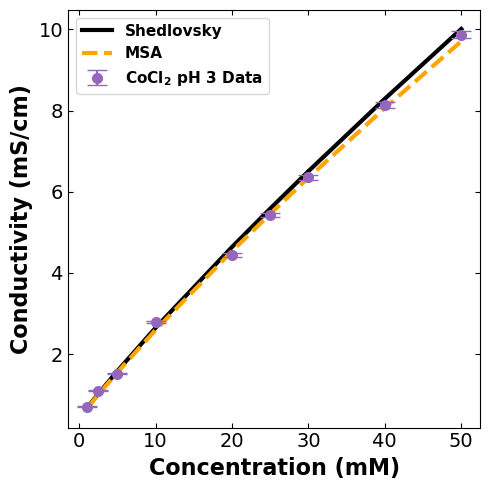

In [45]:
# plot comparing the model predictions with the data
fig = plt.figure(figsize=(5,5))
plt.plot(molar_conc_specific_Co_ph3, specific_cond_calc_Co_H_ph3, "-", color="black", 
         linewidth=3, label="Shedlovsky")
plt.plot(molar_conc_specific_Co_ph3, msa_cond_Co_H_ph3, "--", color="orange", 
         linewidth=3, label="MSA")
plt.errorbar(
    molar_conc_specific_Co_ph3, specific_cond_Co_ph3, yerr=error_Co_ph3, fmt='o', 
    ecolor='tab:purple', capsize=7, markersize=7, markerfacecolor='tab:purple', 
    markeredgecolor='tab:purple', label='CoCl$\mathbf{_2}$ pH 3 Data')
plt.xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold", "size": 11})
plt.tight_layout()
plt.savefig(".\Li_Co\msa_shed_co_h_ph3_paper.png")
plt.show()

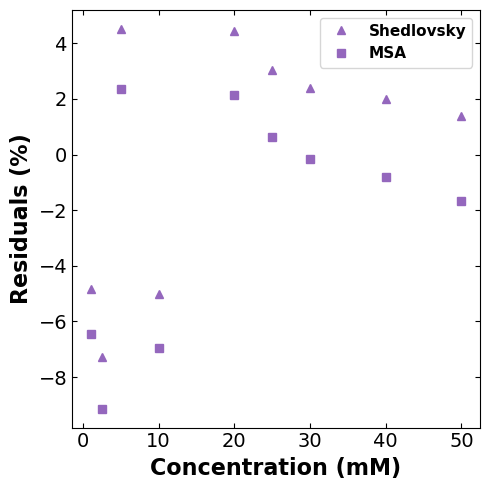

In [46]:
# visualizing the percent prediction residuals
fig = plt.figure(figsize=(5,5))
plt.plot(molar_conc_specific_Co_ph3, residuals_percent_CoCl2_ph3_shed, "^", 
         color="tab:purple", label="Shedlovsky")
plt.plot(molar_conc_specific_Co_ph3, residuals_percent_CoCl2_ph3_msa, "s", 
         color="tab:purple", label="MSA")
plt.xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold", "size": 11})
plt.tight_layout()
plt.savefig(r".\Li_Co\proportion_msa_shed_co_h_ph3_paper.png")
plt.show()

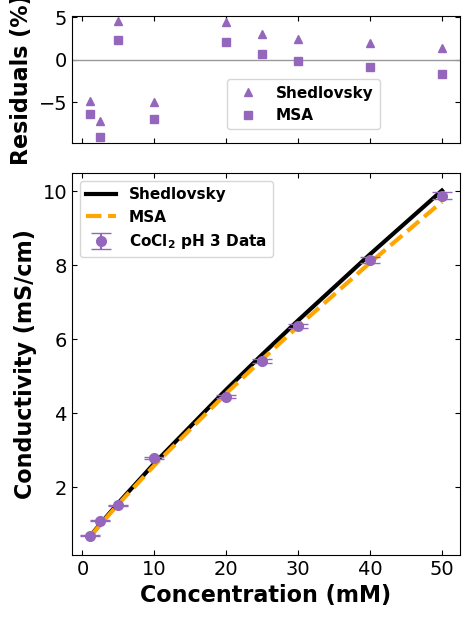

In [47]:
# generate paper figure for the Shedlovsky and MSA models
fig = plt.figure(figsize=(5, 7))
gs = GridSpec(2, 1, height_ratios=[1, 3], hspace=0.12)

ax_res = fig.add_subplot(gs[0])
ax_cond = fig.add_subplot(gs[1], sharex=ax_res)

# top plot
ax_res.axhline(0, color="0.6", lw=1)
ax_res.plot(molar_conc_specific_Co_ph3, residuals_percent_CoCl2_ph3_shed, 
            "^", color="tab:purple", label="Shedlovsky")
ax_res.plot(molar_conc_specific_Co_ph3, residuals_percent_CoCl2_ph3_msa, 
            "s", color="tab:purple", label="MSA")

ax_res.set_ylabel("Residuals (%)", fontsize=16, fontweight="bold")
# ax_res.set_ylim(-10, 6)
ax_res.legend(prop={"weight":"bold", "size": 11}, bbox_to_anchor=(0.4, 0.5), 
              borderaxespad=0, fontsize=12)

ax_res.tick_params(direction="in", top=True, right=True, labelsize=14)
plt.setp(ax_res.get_xticklabels(), visible=False)

# bottom plot
ax_cond.plot(molar_conc_specific_Co_ph3, specific_cond_calc_Co_H_ph3, "-", color="black", 
             linewidth=3, label="Shedlovsky")
ax_cond.plot(molar_conc_specific_Co_ph3, msa_cond_Co_H_ph3, "--", color="orange", 
             linewidth=3, label="MSA")
ax_cond.errorbar(
    molar_conc_specific_Co_ph3, specific_cond_Co_ph3, yerr=error_Co_ph3, fmt='o', 
    ecolor='tab:purple', capsize=7, markersize=7, markerfacecolor='tab:purple', 
    markeredgecolor='tab:purple', label='CoCl$\mathbf{_2}$ pH 3 Data')

ax_cond.set_xlabel("Concentration (mM)", fontsize=16, fontweight="bold")
ax_cond.set_ylabel("Conductivity (mS/cm)", fontsize=16, fontweight="bold")

ax_cond.tick_params(direction="in", top=True, right=True, labelsize=14)

plt.legend(prop={"weight":"bold", "size": 11})
plt.savefig(".\Li_Co\msa_shed_co_h_ph3_paper_final.png")
plt.show()